# Logistic Regression Attack Sweep
Run logistic regression attacks and compare accuracy across temperature and voltage.

## Reproduce this notebook
1. Install dependencies from `pypuf/requirements.txt`.
2. Open this file in Jupyter.
3. Run each cell sequentially to generate the models and plots.

## Example output
![Representative output](../USE_CASE/graphs_metrics/ArbiterPUF_metrics_vs_voltage.png)


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_environmental_heatmap(
    accuracies,
    temp_range,
    vdd_range,
    puf_name,
    attack_name,
    save_full_grid=True,
    save_summary=True
):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(accuracies, cmap="viridis", interpolation='nearest', origin='lower')
    
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Model Accuracy", rotation=-90, va="bottom")

    ax.set_xticks(np.arange(len(vdd_range)))
    ax.set_yticks(np.arange(len(temp_range)))
    ax.set_xticklabels(vdd_range)
    ax.set_yticklabels(temp_range)
    ax.set_xlabel("Vdd (V)")
    ax.set_ylabel("Temperature (°C)")

    ax.set_title(f"{attack_name} Accuracy vs. Environment\nTarget: {puf_name}")
    plt.tight_layout()
    plt.show()

    # ==============================
    # 🔹 FULL GRID CSV (per PUF)
    # ==============================
    if save_full_grid:
        rows = []
        for i, T in enumerate(temp_range):
            for j, V in enumerate(vdd_range):
                rows.append({
                    "PUF_Type": puf_name,
                    "Attack_Type": attack_name,
                    "Temperature": T,
                    "Voltage": V,
                    "Accuracy": float(accuracies[i, j])
                })

        df_full = pd.DataFrame(rows)

        full_csv_name = f"{puf_name}_master_accuracy.csv"

        if os.path.exists(full_csv_name):
            df_full.to_csv(full_csv_name, mode='a', header=False, index=False)
        else:
            df_full.to_csv(full_csv_name, mode='w', header=True, index=False)

        print(f"Saved full grid accuracy to {full_csv_name}")

    # ==============================
    # 🔹 SUMMARY STATS (ALL PUFs)
    # ==============================
    if save_summary:
        flat_acc = accuracies.flatten()

        mean_acc = np.mean(flat_acc)
        std_acc = np.std(flat_acc)
        min_acc = np.min(flat_acc)
        max_acc = np.max(flat_acc)

        summary_row = {
            "PUF_Type": puf_name,
            "Attack_Type": attack_name,
            "Mean_Accuracy": mean_acc,
            "Std_Accuracy": std_acc,
            "Min_Accuracy": min_acc,
            "Max_Accuracy": max_acc,
            "Num_Grid_Points": len(flat_acc)
        }

        df_summary = pd.DataFrame([summary_row])

        summary_csv_name = "ALL_PUF_attack_summary.csv"

        if os.path.exists(summary_csv_name):
            df_summary.to_csv(summary_csv_name, mode='a', header=False, index=False)
        else:
            df_summary.to_csv(summary_csv_name, mode='w', header=True, index=False)

        print(f"Saved summary stats to {summary_csv_name}")
        print(f"Mean: {mean_acc:.4f}, Std: {std_acc:.4f}")


Epoch 1/50
50/50 [==============================] - 1s 12ms/step - loss: 0.6360 - accuracy: 0.6378 - val_loss: 0.5368 - val_accuracy: 0.7560
Epoch 2/50
50/50 [==============================] - 0s 7ms/step - loss: 0.4891 - accuracy: 0.8141 - val_loss: 0.4331 - val_accuracy: 0.8520
Epoch 3/50
50/50 [==============================] - 0s 4ms/step - loss: 0.4072 - accuracy: 0.8783 - val_loss: 0.3708 - val_accuracy: 0.8980
Epoch 4/50
50/50 [==============================] - 0s 3ms/step - loss: 0.3548 - accuracy: 0.9075 - val_loss: 0.3280 - val_accuracy: 0.9240
Epoch 5/50
50/50 [==============================] - 0s 3ms/step - loss: 0.3176 - accuracy: 0.9249 - val_loss: 0.2967 - val_accuracy: 0.9300
Epoch 6/50
50/50 [==============================] - 0s 4ms/step - loss: 0.2896 - accuracy: 0.9373 - val_loss: 0.2725 - val_accuracy: 0.9360
Epoch 7/50
50/50 [==============================] - 0s 5ms/step - loss: 0.2676 - accuracy: 0.9453 - val_loss: 0.2529 - val_accuracy: 0.9440
Epoch 8/50
50/50 [=

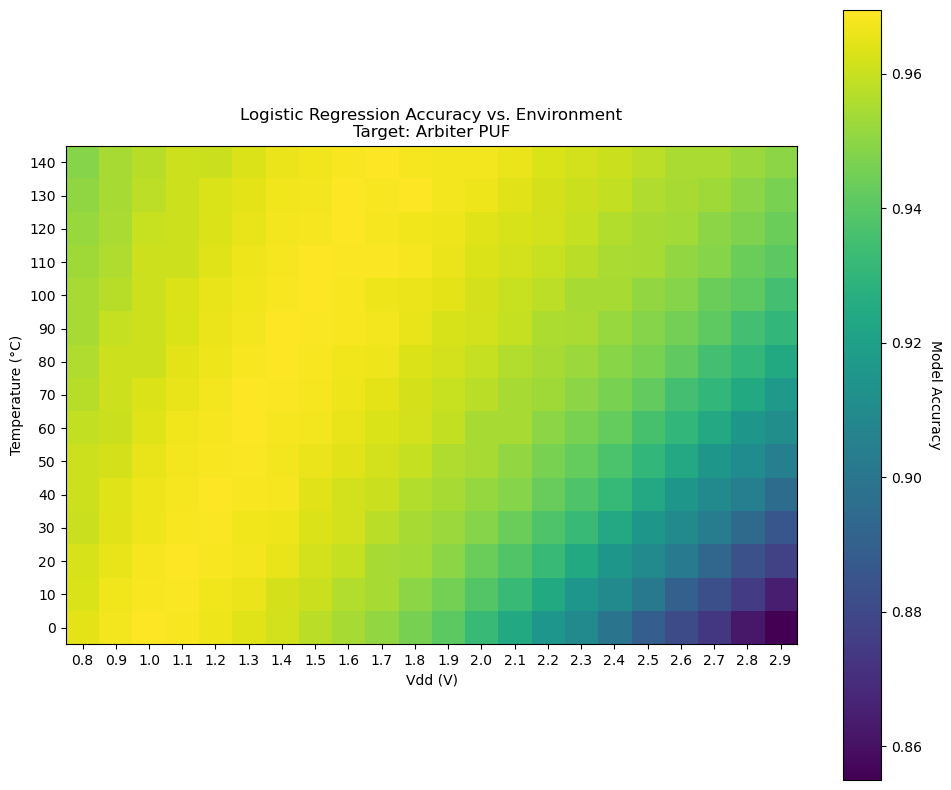

Saved full grid accuracy to Arbiter PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.9507, Std: 0.0222


In [ ]:
from pypuf.simulation import ArbiterPUF
from pypuf.io import ChallengeResponseSet
from pypuf.attack import LRAttack2021
from pypuf.metrics import similarity

# 1. Setup
n_bits, puf_seed = 64, 123
nom_temp, nom_vdd = 25.0, 1.2
n_train, n_test = 50000, 2000
temp_range = np.arange(0, 150, 10)
vdd_range = np.round(np.arange(0.8, 3.00, 0.1), 2)

# 2. Train at Nominal (Golden Point)
p_nom = ArbiterPUF(n=n_bits, seed=puf_seed, noisiness=0.05, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed= puf_seed)
# LR: (crps, seed, k, bs, lr, epochs) [cite: 39, 46]
model = LRAttack2021(train_crps, 42, 1, 1000, 1e-3, 50).fit() #[cite: 58]
model.temperature, model.vdd = nom_temp, nom_vdd


# 3. Environmental Sweep
acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = ArbiterPUF(n=n_bits, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0] #[cite: 358]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Arbiter PUF", "Logistic Regression")

Epoch 1/50
99/99 [==============================] - 2s 8ms/step - loss: 0.6933 - accuracy: 0.4989 - val_loss: 0.6935 - val_accuracy: 0.4880
Epoch 2/50
99/99 [==============================] - 0s 4ms/step - loss: 0.6930 - accuracy: 0.5047 - val_loss: 0.6932 - val_accuracy: 0.5110
Epoch 3/50
99/99 [==============================] - 0s 4ms/step - loss: 0.6927 - accuracy: 0.5105 - val_loss: 0.6923 - val_accuracy: 0.5120
Epoch 4/50
99/99 [==============================] - 0s 5ms/step - loss: 0.6922 - accuracy: 0.5132 - val_loss: 0.6910 - val_accuracy: 0.5190
Epoch 5/50
99/99 [==============================] - 0s 5ms/step - loss: 0.6914 - accuracy: 0.5178 - val_loss: 0.6885 - val_accuracy: 0.5460
Epoch 6/50
99/99 [==============================] - 0s 4ms/step - loss: 0.6864 - accuracy: 0.5360 - val_loss: 0.6777 - val_accuracy: 0.5410
Epoch 7/50
99/99 [==============================] - 0s 5ms/step - loss: 0.6339 - accuracy: 0.6771 - val_loss: 0.5701 - val_accuracy: 0.8410
Epoch 8/50
99/99 [==

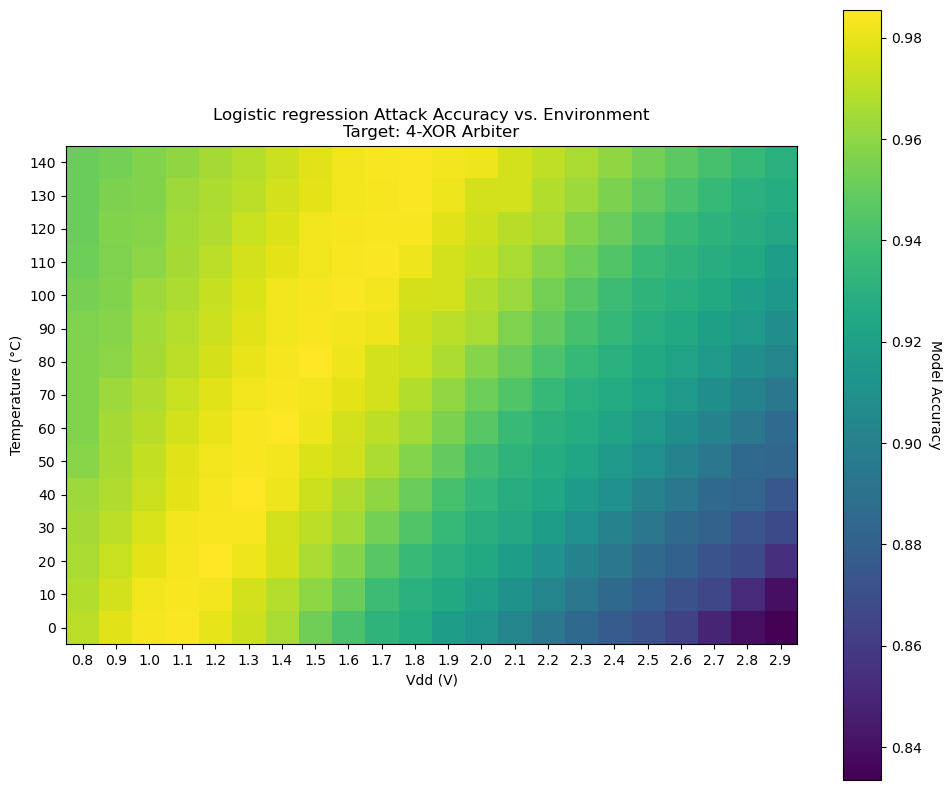

Saved full grid accuracy to 4-XOR Arbiter_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.9470, Std: 0.0341


In [ ]:
from pypuf.simulation import XORArbiterPUF
from pypuf.attack import LRAttack2021

k = 4
p_nom = XORArbiterPUF(n=n_bits, k=k, seed=puf_seed, noisiness=0.05, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=100000, seed=puf_seed) 

# LR Attack: (crps, seed, k, bs, lr, epochs)
model = LRAttack2021(train_crps, seed=42, k=k, bs=1000, lr=1e-3, epochs=50).fit()
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = XORArbiterPUF(n=n_bits, k=k, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, f"{k}-XOR Arbiter", "Logistic regression Attack")

Epoch 1/50
50/50 [==============================] - 1s 9ms/step - loss: 0.7539 - accuracy: 0.5174 - val_loss: 0.6879 - val_accuracy: 0.5620
Epoch 2/50
50/50 [==============================] - 0s 3ms/step - loss: 0.6301 - accuracy: 0.6461 - val_loss: 0.5952 - val_accuracy: 0.7000
Epoch 3/50
50/50 [==============================] - 0s 3ms/step - loss: 0.5601 - accuracy: 0.7337 - val_loss: 0.5400 - val_accuracy: 0.7620
Epoch 4/50
50/50 [==============================] - 0s 3ms/step - loss: 0.5156 - accuracy: 0.7788 - val_loss: 0.5047 - val_accuracy: 0.7800
Epoch 5/50
50/50 [==============================] - 0s 5ms/step - loss: 0.4841 - accuracy: 0.8012 - val_loss: 0.4782 - val_accuracy: 0.8060
Epoch 6/50
50/50 [==============================] - 0s 3ms/step - loss: 0.4601 - accuracy: 0.8138 - val_loss: 0.4582 - val_accuracy: 0.8140
Epoch 7/50
50/50 [==============================] - 0s 3ms/step - loss: 0.4410 - accuracy: 0.8218 - val_loss: 0.4409 - val_accuracy: 0.8200
Epoch 8/50
50/50 [==

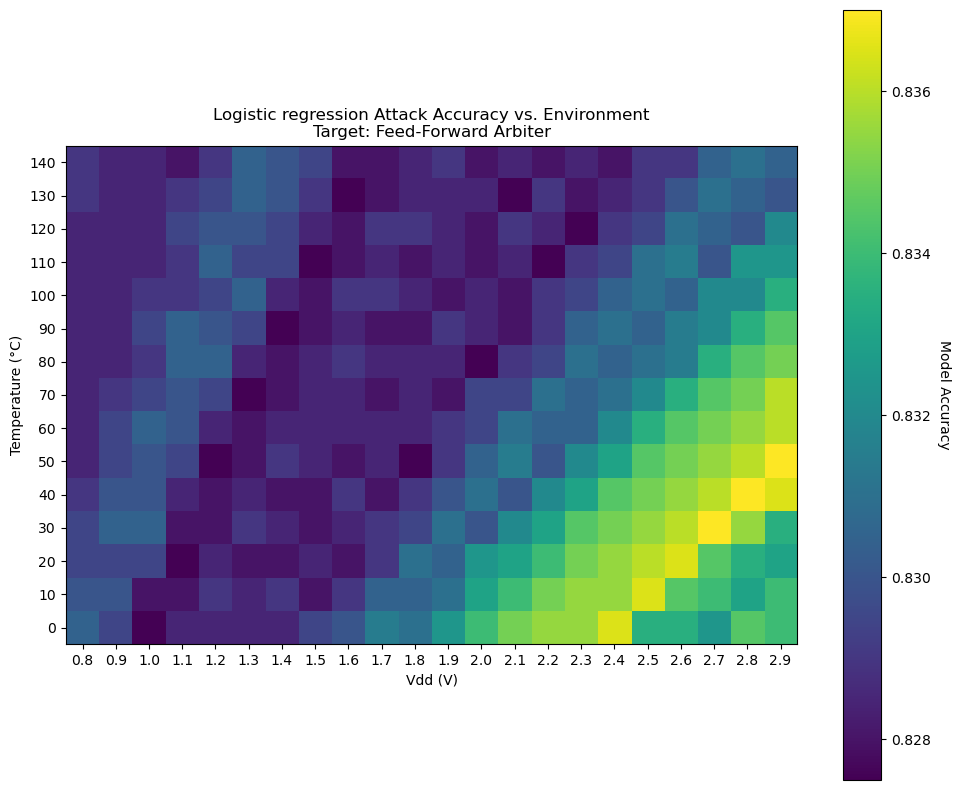

Saved full grid accuracy to Feed-Forward Arbiter_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.8303, Std: 0.0025


In [ ]:
from pypuf.simulation import FeedForwardArbiterPUF

# Define FF bit indices: [(trigger_index, target_index), ...]
ff_config = [(10, 20), (30, 40)]
p_nom = FeedForwardArbiterPUF(n=n_bits, ff=ff_config, seed=puf_seed, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed=puf_seed)

# FF Arbiter is modeled as k=1 for basic LR, though accuracy may vary due to internal dependencies
model = LRAttack2021(train_crps, seed=42, k=1, bs=1000, lr=1e-3, epochs=50).fit()
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = FeedForwardArbiterPUF(n=n_bits, ff=ff_config, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Feed-Forward Arbiter", "Logistic regression Attack")

Epoch 1/50
50/50 [==============================] - 1s 8ms/step - loss: 0.7320 - accuracy: 0.5000 - val_loss: 0.7083 - val_accuracy: 0.4960
Epoch 2/50
50/50 [==============================] - 0s 3ms/step - loss: 0.7001 - accuracy: 0.5011 - val_loss: 0.6958 - val_accuracy: 0.4740
Epoch 3/50
50/50 [==============================] - 0s 4ms/step - loss: 0.6941 - accuracy: 0.5014 - val_loss: 0.6936 - val_accuracy: 0.4980
Epoch 4/50
50/50 [==============================] - 0s 3ms/step - loss: 0.6932 - accuracy: 0.5075 - val_loss: 0.6947 - val_accuracy: 0.4900
Epoch 5/50
50/50 [==============================] - 0s 3ms/step - loss: 0.6931 - accuracy: 0.5091 - val_loss: 0.6937 - val_accuracy: 0.5040
Epoch 6/50
50/50 [==============================] - 0s 3ms/step - loss: 0.6931 - accuracy: 0.5071 - val_loss: 0.6933 - val_accuracy: 0.5160
Epoch 7/50
50/50 [==============================] - 0s 3ms/step - loss: 0.6931 - accuracy: 0.5097 - val_loss: 0.6936 - val_accuracy: 0.5320
Epoch 8/50
50/50 [==

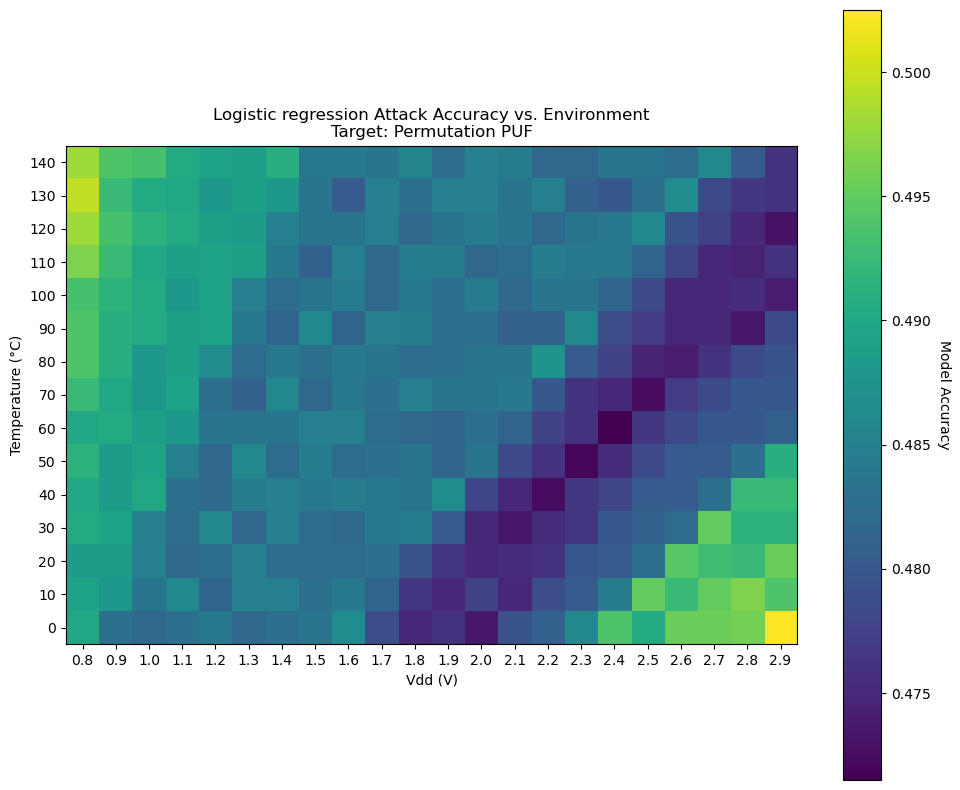

Saved full grid accuracy to Permutation PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.4838, Std: 0.0056


In [ ]:
from pypuf.simulation import PermutationPUF

# 1. Setup Data Generation
p_nom = PermutationPUF(n=n_bits, seed=puf_seed, temperature=nom_temp, vdd=nom_vdd, k=8)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed=puf_seed)

# 2. Run LR Attack
model = LRAttack2021(train_crps, seed=42, k=1, bs=1000, lr=1e-3, epochs=50).fit()
model.temperature, model.vdd = nom_temp, nom_vdd

# 3. Environmental Sweep
acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = PermutationPUF(n=n_bits, seed=puf_seed, temperature=t, vdd=v, k=8)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Permutation PUF", "Logistic regression Attack")

Epoch 1/50
297/297 [==============================] - 2s 4ms/step - loss: 0.6773 - accuracy: 0.5582 - val_loss: 0.6409 - val_accuracy: 0.6483
Epoch 2/50
297/297 [==============================] - 1s 3ms/step - loss: 0.6148 - accuracy: 0.6841 - val_loss: 0.6119 - val_accuracy: 0.6917
Epoch 3/50
297/297 [==============================] - 1s 3ms/step - loss: 0.5952 - accuracy: 0.7103 - val_loss: 0.5945 - val_accuracy: 0.7187
Epoch 4/50
297/297 [==============================] - 1s 3ms/step - loss: 0.5803 - accuracy: 0.7209 - val_loss: 0.5845 - val_accuracy: 0.7133
Epoch 5/50
297/297 [==============================] - 1s 3ms/step - loss: 0.5714 - accuracy: 0.7211 - val_loss: 0.5796 - val_accuracy: 0.7163
Epoch 6/50
297/297 [==============================] - 1s 3ms/step - loss: 0.5679 - accuracy: 0.7229 - val_loss: 0.5770 - val_accuracy: 0.7217
Epoch 7/50
297/297 [==============================] - 1s 2ms/step - loss: 0.5659 - accuracy: 0.7239 - val_loss: 0.5755 - val_accuracy: 0.7180
Epoch 

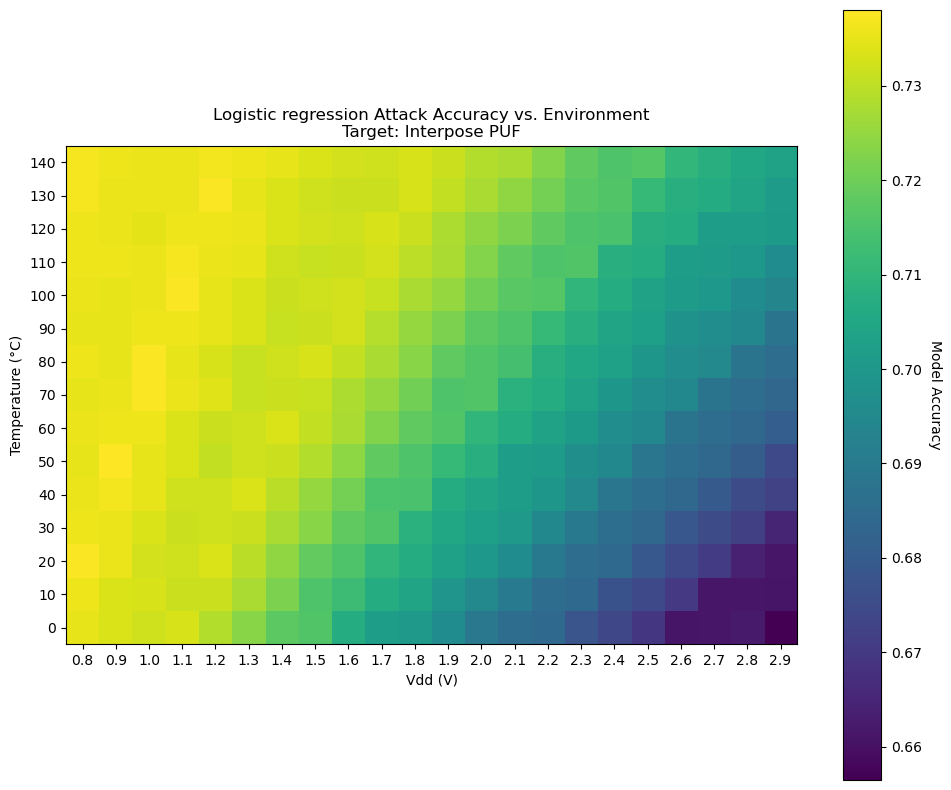

Saved full grid accuracy to Interpose PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.7141, Std: 0.0208


In [ ]:
from pypuf.simulation import InterposePUF

# k_up and k_down represent the top and bottom Arbiter chains
k_up, k_down = 2, 2
p_nom = InterposePUF(n=n_bits, k_up=k_up, k_down=k_down, seed=puf_seed, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=300000, seed=puf_seed) 

# Logistic Regression treats the combined Interpose structure as a k-XOR problem (k_up + k_down)
model = LRAttack2021(train_crps, seed=42, k=k_up + k_down, bs=1000, lr=1e-3, epochs=50).fit()
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = InterposePUF(n=n_bits, k_up=k_up, k_down=k_down, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Interpose PUF", "Logistic regression Attack")